# Построение датасета для Spell Correction (30 000 примеров)

## Распределение датасета

| Категория | Источник | Примеров |
|---|---|---|
| Готовые пары | russian_gec_dataset | ~25 000 |
| Готовые пары | RUSpellRU | ~2 000 |
| Готовые пары | MultidomainGold | ~3 569 |
| **ИТОГО** | | **30 569** |

## 1. Импорты и константы

In [ ]:
import random
import json
from pathlib import Path
from difflib import SequenceMatcher

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

# Воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Пути
OUTPUT_DIR = Path("../data/spell_corr_datasets")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / "spell_correction_30k.csv"
JSON_PATH = OUTPUT_DIR / "spell_correction_30k.json"

## 2. Загрузка готовых датасетов spell correction

In [ ]:
records = []  # список словарей {'text': ..., 'text_corrupt': ..., 'source': ..., 'method': ...}

# 2.1 russian_gec_dataset
df_gec = pd.read_csv("data/spell_corr_datasets/russian_gec_dataset.csv")
for _, row in df_gec.iterrows():
    records.append(
        {
            "text": row["correct"],
            "text_corrupt": row["incorrect"],
            "source": "russian_gec_dataset",
            "method": "ready_pair",
        }
    )
print(f"russian_gec_dataset: {len(df_gec):,} пар")

russian_gec_dataset: 24,998 пар


In [ ]:
# 2.2 RUSpellRU
from sage.utils import DatasetsAvailable, load_available_dataset_from_hf

ru_sources, ru_corrections = load_available_dataset_from_hf(
    DatasetsAvailable.RUSpellRU.name, for_labeler=True, split="train"
)
for src, corr in zip(ru_sources, ru_corrections):
    records.append(
        {
            "text": corr,
            "text_corrupt": src,
            "source": "RUSpellRU",
            "method": "ready_pair",
        }
    )
print(f"RUSpellRU: {len(ru_sources):,} пар")

RUSpellRU: 2,000 пар


In [ ]:
# 2.3 MultidomainGold
md_sources, md_corrections = load_available_dataset_from_hf(
    DatasetsAvailable.MultidomainGold.name, for_labeler=True, split="train"
)
for src, corr in zip(md_sources, md_corrections):
    records.append(
        {
            "text": corr,
            "text_corrupt": src,
            "source": "MultidomainGold",
            "method": "ready_pair",
        }
    )
print(f"MultidomainGold: {len(md_sources):,} пар")
print(f"\nИтого готовых пар: {len(records):,}")

MultidomainGold: 3,569 пар

Итого готовых пар: 30,567


## 3. Финализация датасета

In [ ]:
df = pd.DataFrame(records)
print(f"Размер датасета до финализации: {len(df):,}")

# Убираем строки с пустыми значениями
df = df.dropna(subset=["text", "text_corrupt"])
df = df[df["text"].str.strip().str.len() > 0]
df = df[df["text_corrupt"].str.strip().str.len() > 0]
df = df.reset_index(drop=True)

# Перемешиваем
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Итоговый размер датасета: {len(df):,}")
df.head(3)

Размер датасета до финализации: 30,567
Итоговый размер датасета: 30,567


,text,text_corrupt,source,method
0,Я люблю готовить различные блюда и часто пригл...,Я люблю готовить различный блюда и часто пригл...,russian_gec_dataset,ready_pair
1,Я планирую сходить в магазин завтра и купить н...,Я планирую сходить в магазин завтра и купить н...,russian_gec_dataset,ready_pair
2,Вскоре после сельских Дионисий в самих Афинах ...,Вскоре после сельских Дионисий в самих Афинах ...,MultidomainGold,ready_pair


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30567 entries, 0 to 30566
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   text          30567 non-null  str  
 1   text_corrupt  30567 non-null  str  
 2   source        30567 non-null  str  
 3   method        30567 non-null  str  
dtypes: str(4)
memory usage: 10.7 MB


## 4. Сохранение в CSV

In [ ]:
df.to_csv(CSV_PATH, index=False, encoding="utf-8")
print(f"CSV сохранён: {CSV_PATH}  ({CSV_PATH.stat().st_size / 1e6:.1f} MB)")

## 5. Сохранение в JSON (формат LLaMA Factory)

In [ ]:
SPELL_CORR_PROMPT_TEMPLATE = """Исходный текст:
{text}

Отредактируй исходный текст, исправив ошибки.
"""


def get_messages_object_for_row(row, prompt_template=None):
    if not prompt_template:
        prompt_template = SPELL_CORR_PROMPT_TEMPLATE
    user_prompt = prompt_template.format(text=row["text_corrupt"])
    return {
        "messages": [
            {"content": user_prompt, "role": "user"},
            {"content": row["text"], "role": "assistant"},
        ],
    }


train_dataset = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Building JSON"):
    train_dataset.append(get_messages_object_for_row(row))

with open(JSON_PATH, "w", encoding="utf-8") as fout:
    json.dump(train_dataset, fout, indent=2, ensure_ascii=False)

print(f"JSON сохранён: {JSON_PATH}  ({JSON_PATH.stat().st_size / 1e6:.1f} MB)")

## 6. Статистики по датасету

In [3]:
print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ")
print("=" * 60)
print(f"Всего примеров:       {len(df):>10,}")
print(f"Уникальных text:      {df['text'].nunique():>10,}")
print(f"Уникальных corrupt:   {df['text_corrupt'].nunique():>10,}")
print()

# Добавляем вспомогательные столбцы
df["text_len"] = df["text"].str.len()
df["corrupt_len"] = df["text_corrupt"].str.len()
df["is_changed"] = df["text"] != df["text_corrupt"]

print("ПРОЦЕНТ ИЗМЕНЁННЫХ ПРИМЕРОВ")
print(
    f"  Изменено:    {df['is_changed'].sum():>10,} ({df['is_changed'].mean() * 100:.1f}%)"
)
print(
    f"  Не изменено: {(~df['is_changed']).sum():>10,} ({(~df['is_changed']).mean() * 100:.1f}%)"
)
print()

ОБЩАЯ ИНФОРМАЦИЯ
Всего примеров:           30,567
Уникальных text:          23,135
Уникальных corrupt:       30,202

ПРОЦЕНТ ИЗМЕНЁННЫХ ПРИМЕРОВ
  Изменено:        29,794 (97.5%)
  Не изменено:        773 (2.5%)



In [4]:
print("РАСПРЕДЕЛЕНИЕ ПО МЕТОДАМ")
method_counts = df["method"].value_counts()
print(method_counts.to_string())
print()

РАСПРЕДЕЛЕНИЕ ПО МЕТОДАМ
method
ready_pair    30567



In [5]:
print("РАСПРЕДЕЛЕНИЕ ПО ИСТОЧНИКАМ")
source_counts = df["source"].value_counts()
print(source_counts.to_string())
print()

РАСПРЕДЕЛЕНИЕ ПО ИСТОЧНИКАМ
source
russian_gec_dataset    24998
MultidomainGold         3569
RUSpellRU               2000



In [6]:
print("ДЛИНЫ ТЕКСТОВ (символов)")
for col, label in [("text_len", "Оригинал"), ("corrupt_len", "Испорченный")]:
    s = df[col]
    print(f"  {label}:")
    print(
        f"    min={s.min()}, max={s.max()}, mean={s.mean():.1f}, median={s.median():.1f}"
    )
print()

ДЛИНЫ ТЕКСТОВ (символов)
  Оригинал:
    min=6, max=1104, mean=84.2, median=69.0
  Испорченный:
    min=5, max=1084, mean=84.1, median=68.0



In [7]:
df["text_len"].describe()

count    30567.000000
mean        84.222822
std         95.361605
min          6.000000
25%         60.000000
50%         69.000000
75%         78.000000
max       1104.000000
Name: text_len, dtype: float64

In [8]:
df["corrupt_len"].describe()

count    30567.000000
mean        84.075899
std         94.963837
min          5.000000
25%         59.000000
50%         68.000000
75%         77.000000
max       1084.000000
Name: corrupt_len, dtype: float64

In [ ]:
# Степень изменения: CER (Character Error Rate) на подвыборке
SAMPLE_SIZE = 5000
sample_df = df[df["is_changed"]].sample(
    min(SAMPLE_SIZE, df["is_changed"].sum()), random_state=SEED
)


def cer(orig, corr):
    """Character Error Rate."""
    if len(orig) == 0:
        return 0.0
    m = SequenceMatcher(None, orig, corr)
    return 1 - m.ratio()


cers = [
    cer(row["text"], row["text_corrupt"])
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="CER")
]

print(f"CER (на {len(sample_df):,} изменённых примерах):")
print(f"  mean={np.mean(cers):.3f}, median={np.median(cers):.3f}, ")
print(f"  p10={np.percentile(cers, 10):.3f}, p90={np.percentile(cers, 90):.3f}")

CER:   0%|          | 0/5000 [00:00<?, ?it/s]

CER: 100%|██████████| 5000/5000 [00:01<00:00, 4397.94it/s]

CER (на 5,000 изменённых примерах):
  mean=0.051, median=0.038, 
  p10=0.014, p90=0.089


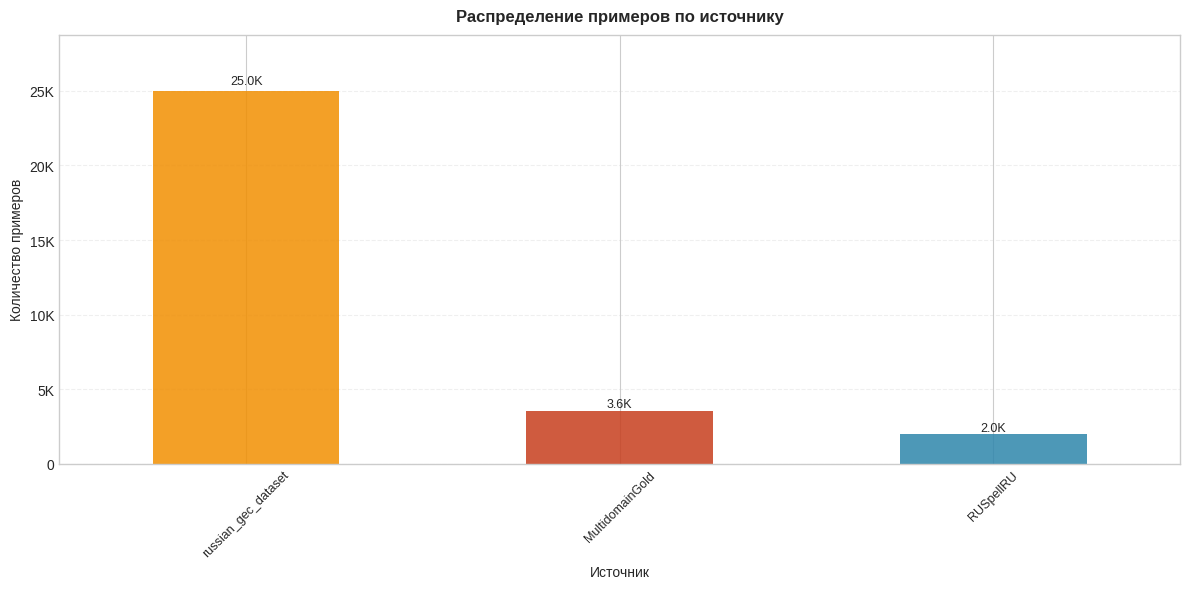

✓ График "distribution_by_source.png" сохранён


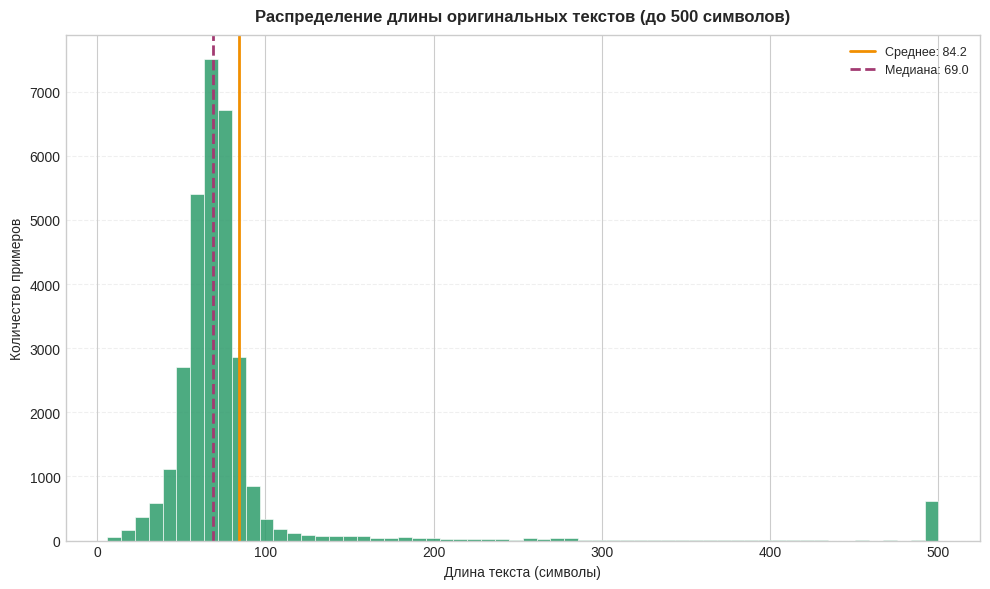

✓ График "text_length_histogram.png" сохранён


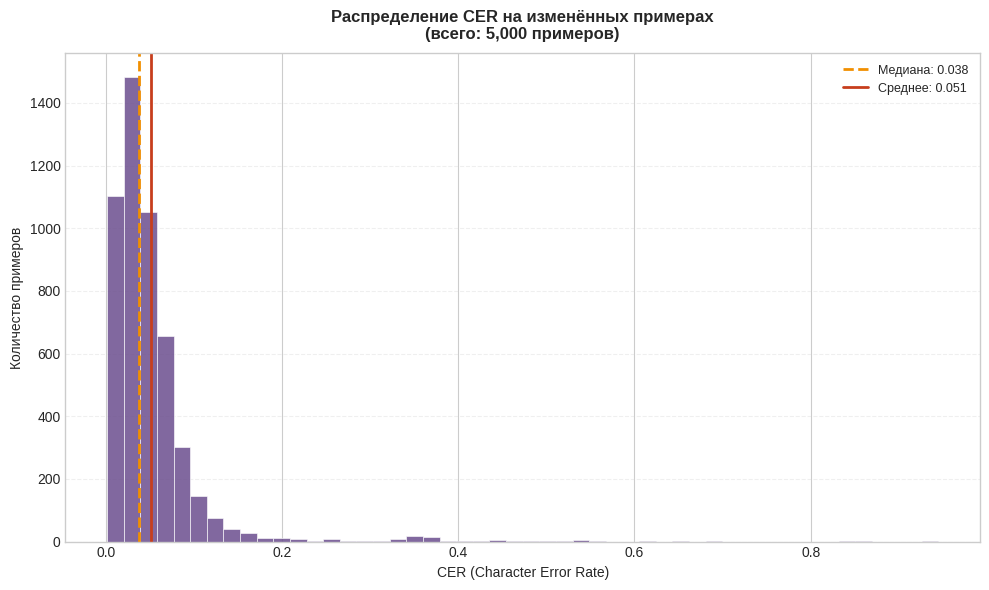

✓ График "cer_histogram.png" сохранён


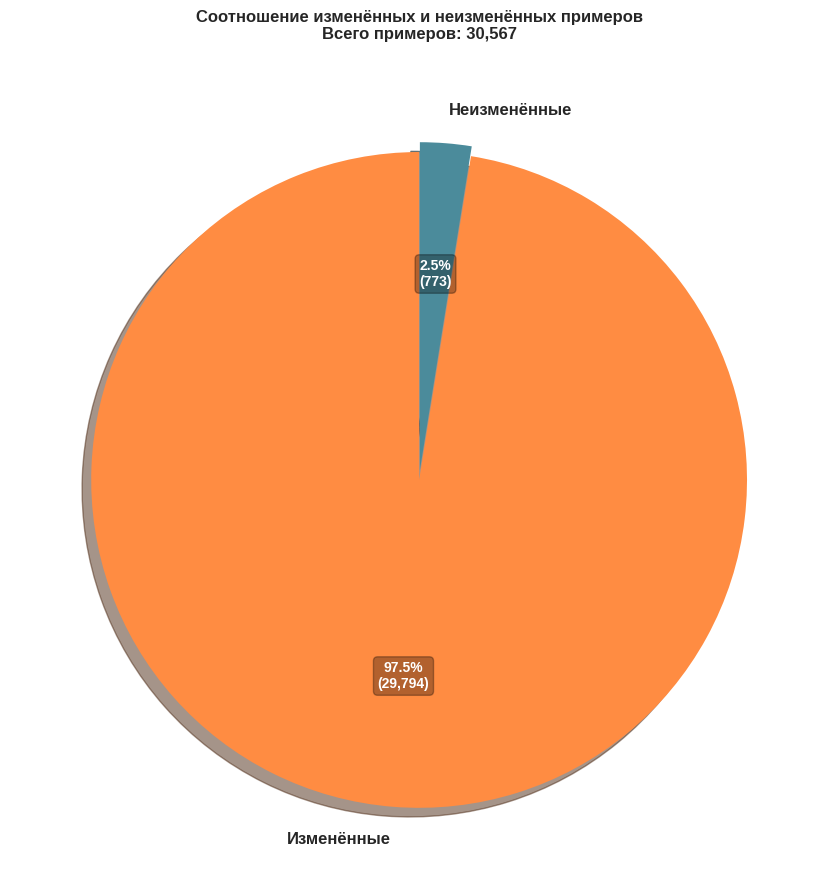

✓ График "is_changed_pie.png" сохранён


In [13]:
# Визуализация
output_dir = Path("data/graphics/spell_correction_30k")

# Единые настройки стиля для всех графиков
plt.style.use("seaborn-v0_8-whitegrid")
colors_palette = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent1": "#F18F01",
    "accent2": "#C73E1D",
    "green": "#2E9C6B",
    "purple": "#6B4E8E",
    "pie1": "#FF8C42",
    "pie2": "#4B8B9B",
}

# 1. Распределение по источникам (bar, разные цвета)
fig2, ax2 = plt.subplots(figsize=(12, 6))
colors = [
    colors_palette["accent1"],
    colors_palette["accent2"],
    colors_palette["primary"],
    colors_palette["secondary"],
    colors_palette["green"],
][: len(source_counts)]
bars = source_counts.plot(kind="bar", ax=ax2, color=colors, legend=False, alpha=0.85)
ax2.set_title(
    "Распределение примеров по источнику", fontsize=12, fontweight="bold", pad=10
)
ax2.set_ylabel("Количество примеров", fontsize=10)
ax2.set_xlabel("Источник", fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}K" if x >= 1000 else f"{x:.0f}")
)
ax2.set_ylim(0, source_counts.max() * 1.15)
ax2.tick_params(axis="x", rotation=45, labelsize=9)
ax2.grid(axis="y", alpha=0.3, linestyle="--")
# Добавляем значения на столбцы
for bar, value in zip(ax2.patches, source_counts.values):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + height * 0.01,
        f"{value / 1e3:.1f}K" if value >= 1000 else f"{value:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(output_dir / "distribution_by_source.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "distribution_by_source.png" сохранён')

# 2. Гистограмма длин оригинальных текстов
fig3, ax3 = plt.subplots(figsize=(10, 6))
df["text_len"].clip(upper=500).hist(
    bins=60,
    ax=ax3,
    color=colors_palette["green"],
    edgecolor="white",
    alpha=0.85,
    linewidth=0.5,
)
ax3.set_title(
    "Распределение длины оригинальных текстов (до 500 символов)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax3.set_xlabel("Длина текста (символы)", fontsize=10)
ax3.set_ylabel("Количество примеров", fontsize=10)
ax3.grid(axis="y", alpha=0.3, linestyle="--")
# Добавляем линию среднего и медианы
mean_val = df["text_len"].mean()
median_val = df["text_len"].median()
ax3.axvline(
    mean_val,
    color=colors_palette["accent1"],
    linestyle="-",
    linewidth=2,
    label=f"Среднее: {mean_val:.1f}",
)
ax3.axvline(
    median_val,
    color=colors_palette["secondary"],
    linestyle="--",
    linewidth=2,
    label=f"Медиана: {median_val:.1f}",
)
ax3.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(output_dir / "text_length_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "text_length_histogram.png" сохранён')

# 3. Гистограмма CER
fig4, ax4 = plt.subplots(figsize=(10, 6))
ax4.hist(
    cers,
    bins=50,
    color=colors_palette["purple"],
    edgecolor="white",
    alpha=0.85,
    linewidth=0.5,
)
ax4.set_title(
    f"Распределение CER на изменённых примерах\n(всего: {len(sample_df):,} примеров)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax4.set_xlabel("CER (Character Error Rate)", fontsize=10)
ax4.set_ylabel("Количество примеров", fontsize=10)
ax4.grid(axis="y", alpha=0.3, linestyle="--")
# Добавляем линию медианы
median_cer = np.median(cers)
mean_cer = np.mean(cers)
ax4.axvline(
    median_cer,
    color=colors_palette["accent1"],
    linestyle="--",
    linewidth=2,
    label=f"Медиана: {median_cer:.3f}",
)
ax4.axvline(
    mean_cer,
    color=colors_palette["accent2"],
    linestyle="-",
    linewidth=2,
    label=f"Среднее: {mean_cer:.3f}",
)
ax4.legend(loc="upper right", fontsize=9)
# Добавляем текст с квантилями
plt.tight_layout()
plt.savefig(output_dir / "cer_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "cer_histogram.png" сохранён')

# 4. Pie plot для is_changed (изменённые vs неизменённые примеры)
fig5, ax5 = plt.subplots(figsize=(9, 9))
changed_counts = df["is_changed"].value_counts()
labels = (
    ["Изменённые", "Неизменённые"]
    if True in changed_counts.index
    else changed_counts.index.astype(str)
)
values = changed_counts.values
total = sum(values)


def autopct_format(pct):
    absolute = int(round(pct / 100.0 * total))
    return f"{pct:.1f}%\n({absolute:,})"


wedges, texts, autotexts = ax5.pie(
    values,
    labels=labels,
    autopct=autopct_format,
    colors=[colors_palette["pie1"], colors_palette["pie2"]],
    startangle=90,
    explode=(0.03, 0),
    shadow=True,
    textprops={"fontsize": 11},
)

# Стилизация текста
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight("bold")
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_bbox(dict(boxstyle="round", facecolor="black", alpha=0.3))

ax5.set_title(
    f"Соотношение изменённых и неизменённых примеров\nВсего примеров: {total:,}",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.savefig(output_dir / "is_changed_pie.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print('✓ График "is_changed_pie.png" сохранён')

In [ ]:
# Примеры из каждого метода
print("\nПРИМЕРЫ (по 2 на каждый метод):")
print("=" * 80)
for method in df["method"].unique():
    subset = df[df["method"] == method].sample(
        min(2, (df["method"] == method).sum()), random_state=SEED
    )
    print(f"\n[{method}]")
    for _, row in subset.iterrows():
        orig = row["text"][:120].replace("\n", " ")
        corr = row["text_corrupt"][:120].replace("\n", " ")
        print(f"  ОРИГИНАЛ:    {orig}")
        print(f"  ИСПОРЧЕННЫЙ: {corr}")
        print()


ПРИМЕРЫ (по 2 на каждый метод):

[ready_pair]
  ОРИГИНАЛ:    Моя сестра учит английский и каждый день говорит по скайпу с носителями языка.
  ИСПОРЧЕННЫЙ: Моя сестра учит английский и каждый день говорит на скайпу с носителями языка.

  ОРИГИНАЛ:    Мой друг каждый вечер играет в футбол на стадионе у нашего дома.
  ИСПОРЧЕННЫЙ: Мой друг каждый вечер играет на футболе на стадионе у нашего дома.



In [ ]:
# Итоговая сводка
print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(f"CSV:  {CSV_PATH}")
print(f"JSON: {JSON_PATH}")
print()
print(
    df.groupby("method")
    .agg(
        count=("text", "count"),
        changed_pct=("is_changed", lambda x: f"{x.mean() * 100:.1f}%"),
        avg_orig_len=("text_len", lambda x: f"{x.mean():.0f}"),
    )
    .to_string()
)


ИТОГОВАЯ СВОДКА
CSV:  data/output/spell_correction_30k.csv
JSON: data/output/spell_correction_30k.json

            count changed_pct avg_orig_len
method                                    
ready_pair  30567       97.5%           84
